# Options and Volatility Smile

An equity option represents the right to buy ("call" option) or sell ("put" option) a unit of underlying stock at a prespecified price (strike) at a predetermined maturity date (European option) or at any time up to the predetermined date (American option).

Option writer sells an option and option holder buys an option.

For a European call option on an index with strike 8,000 and index level of 8200 at maturity, the option holder receives the difference of $200 from option writer. This is called the instrinsic value or payoff of the option from the holder's point of view.

The payoff function for a call option is

$$h_{T}(S,K) = max[S_{T}-K, 0]\tag{Eq. 1}$$

where T = maturity date, $S_{T}$ is the index level at maturity and K is the strike price.

Option has moneyness :

In-the-money: a call (put) is in-the-money when S > K (S < K)  
At-the-money: call or put is at-the-money when $S \approx K$    
Out-of-the-money: a call is out-of-the-money when S < K (S > K)    

A fair present value (is different than payoff) of a European call option is given by Black-Scholes formula:

$$C_{0}^{*} = C^{BSM}(S_{0},K,T,r,\sigma)\tag{Eq. 2}$$ 

$S_{0}$ current index level (spot)   
K strike price of the option    
T time-to-maturity of the option    
r risk-free short rate   
$\sigma$ volatility or the std dev of the index returns  

$C^{BSM} = S_{t} . N(d_{1}) - e^{r(T-t)} . K. N(d_{2})\tag{Eq. 3}$

where

$\displaystyle N(d) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d} e^{-\frac{1}{2}x^{2}} dx$

$\displaystyle d1 = \frac{\log\frac{S_{t}}{K} + (r + \frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}}$

$\displaystyle d2 = \frac{\log\frac{S_{t}}{K} + (r - \frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}}$

In [7]:
# BSM option valuation
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
%matplotlib inline

## Helper functions ##
def dN(x):
    ''' Probability density function of standard normal random variable x.'''
    
    return math.exp(-0.5 * x ** 2) / math.sqrt(2 * math.pi)

def N(d):
    ''' Cumulative density function of standard normal random variable x. '''
    
    return quad(lambda x: dN(x), -20, d, limit=50)[0]

def d1f(St, K, t, T, r, sigma):
    ''' Black-Scholes-Merton d1 function.
        Parameters see e.g. BSM_call_value function. '''
    
    d1 = (math.log(St / K) + (r + 0.5 * sigma ** 2)
        * (T - t)) / (sigma * math.sqrt(T - t))
    return d1

def BSM_call_value(St, K, t, T, r, sigma):
    ''' Calculates Black-Scholes-Merton European call option value
        Parameters
    ==========
    St: float
    stock/index level at time t
    K: float
    strike price
    t: float
    valuation date
    T: float
    date of maturity/time-to-maturity if t = 0; T > t
    r: float
    constant, risk-less short rate
    sigma: float
    volatility
    Returns
    =======
    call_value: float
    European call present value at t
    '''
    
    d1 = d1f(St, K, t, T, r, sigma)
    d2 = d1 - sigma * math.sqrt(T - t)
    call_value = St * N(d1) - math.exp(-r * (T - t)) * K * N(d2)
    return call_value

def BSM_put_value(St, K, t, T, r, sigma):
    ''' Calculates Black-Scholes-Merton European put option value.
    Parameters
    ==========
    St: float
    stock/index level at time t
    K: float
    strike price
    t: float
    valuation date
    T: float
    date of maturity/time-to-maturity if t = 0; T > t
    r: float
    constant, risk-less short rate
    sigma: float
    volatility
    Returns
    =======
    put_value: float
    European put present value at t
    '''
    put_value = BSM_call_value(St, K, t, T, r, sigma) - St + math.exp(-r * (T - t)) * K
    return put_value

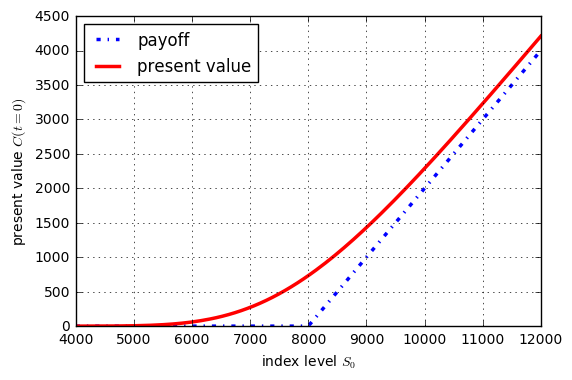

In [8]:
# Test Option Payoff and Time value
K = 8000 # Strike price
T = 1.0 # time-to-maturity
r = 0.025 # constant, risk-free rate
vol = 0.2 # constant volatility

# Generate spot prices 
S = np.linspace(4000, 12000, 150)
h = np.maximum(S - K, 0) # payoff of the option
C = [BSM_call_value(Szero, K, 0, T, r, vol) for Szero in S] #BS call option values

_ = plt.figure()
_ = plt.plot(S, h, 'b-.', lw=2.5, label='payoff') # plot inner value at maturity
_ = plt.plot(S, C, 'r', lw=2.5, label='present value') # plot option present value
_ = plt.grid(True)
_ = plt.legend(loc=0)
_ = plt.xlabel('index level $S_0$')
_ = plt.ylabel('present value $C(t=0)$')

The present value of the option is always higher than the undiscounted payoff, the difference being the time value. In other words, the option's present value is composed of payoff plus the time value. Time value indicates that there is always a chance of option going in-the-money or more in-the-money during that time.

### Simulating Returns###

The geometric brownian motion model of the BS equation is given by

$$\displaystyle dS_{t} = rS_{t}dt + \sigma S_{t} dt dZ_{t}\tag{Eq.4}$$

The discretized version is 

$$\displaystyle S_{t} = S_{t - \Delta t} e^{(r - \frac{1}{2}\sigma^2) \Delta t + \sigma \sqrt{\Delta t} z_{t}}\tag{Eq.5}$$

where t $\in {(\Delta t, 2\Delta t,.....,T)}$

Using the above discretized version, we will simulate the spot prices with $S_{0}$=100, T=10,   r = 0.05 and $\sigma$=0.2

In [9]:
import pandas as pd

# model parameters
S0 = 100.0 # initial index level
T = 10.0 # time horizon
r = 0.05 # risk-less short rate
vol = 0.2 # instantaneous volatility
# simulation parameters
np.random.seed(250000)
#generate a pd array with business dates, ignores holidays
gbm_dates = pd.DatetimeIndex(start='10-05-2007',end='10-05-2017',freq='B')
M = len(gbm_dates) # time steps
I = 1 # index level paths
dt = 1 / 252. # 252 business days a year
df = math.exp(-r * dt) # discount factor

# stock price paths
rand = np.random.standard_normal((M, I)) # random numbers
S = np.zeros_like(rand) # stock matrix
S[0] = S0 # initial values
for t in range(1, M): # stock price paths using Eq.5
    S[t] = S[t - 1] * np.exp((r - vol ** 2 / 2) * dt + vol * rand[t] * math.sqrt(dt))
#create a pd dataframe with date as index and a column named "spot"
gbm = pd.DataFrame(S[:, 0], index=gbm_dates, columns=['spot']) 
gbm['returns'] = np.log(gbm['spot'] / gbm['spot'].shift(1)) #log returns
# Realized Volatility 
gbm['rea_var'] = 252 * np.cumsum(gbm['returns'] ** 2) / np.arange(len(gbm))
gbm['rea_vol'] = np.sqrt(gbm['rea_var'])
print gbm.head()
gbm = gbm.dropna()

                  spot   returns   rea_var   rea_vol
2007-10-05  100.000000       NaN       NaN       NaN
2007-10-08   98.904295 -0.011018  0.030589  0.174898
2007-10-09   98.444867 -0.004656  0.018026  0.134261
2007-10-10   97.696364 -0.007632  0.016911  0.130041
2007-10-11   98.280594  0.005962  0.014922  0.122158


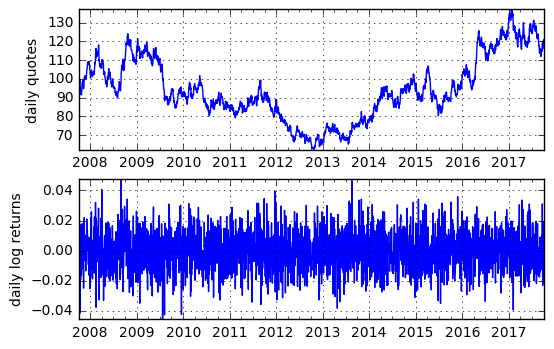

In [12]:
_ = plt.figure()
_ = plt.subplot(211)
_ = gbm['spot'].plot()
_ = plt.ylabel('daily quotes')
_ = plt.grid(True)
_ = plt.axis('tight')
_ = plt.subplot(212)
_ = gbm['returns'].plot()
_ = plt.ylabel('daily log returns')
_ = plt.grid(True)
_ = plt.axis('tight')

**Implied volatility** is the value of $\sigma$ that solves Eq. 2 given the option market quote $C_{0}^{*}$ Volatility surface means the volatilities implied for different option strikes and different option maturities on the same underlying. Vol Surfaces exhibit following :
**Smiles**: option implied volatilities exhibit a smile form, i.e. for calls the OTM implied volatilities are higher than the ATM ones; sometimes they rise again for ITM options
**term structure**:smiles are more pronounced for short-term options than for longer-term
options; a phenomenon sometimes called volatility term structure

,Date,Strike,Call_Bid,Call_Ask,Call,Maturity,Put_Bid,Put_Ask,Put,Imp_Vol
0,2017-05-11,149.0,4.45,4.599999,4.525,2017-05-19,0.280000,0.290000,0.285,0.019668
1,2017-05-11,150.0,3.60,3.650001,3.625,2017-05-19,0.390000,0.410000,0.400,0.018042
2,2017-05-11,152.5,1.75,1.770000,1.760,2017-05-19,1.020000,1.040000,1.030,0.107453
3,2017-05-11,155.0,0.66,0.670000,0.665,2017-05-19,2.420000,2.440001,2.430,0.127970
4,2017-05-11,157.5,0.21,0.220000,0.215,2017-05-19,4.400001,4.550000,4.475,0.142701


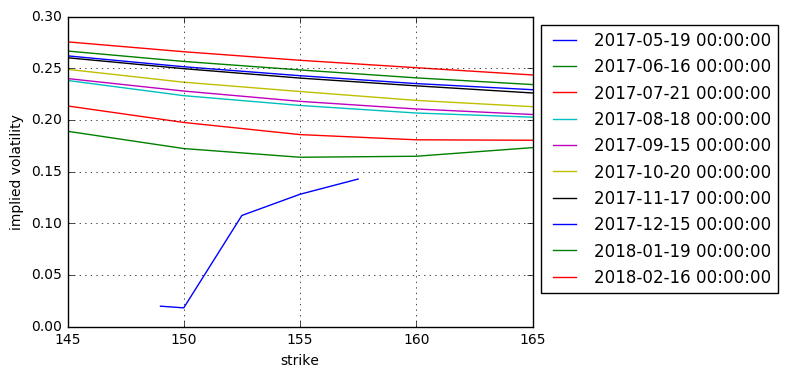

In [16]:
from scipy.optimize import fsolve
import pandas as pd
from matplotlib.font_manager import FontProperties

headers = ['Date','Strike','Call_Bid','Call_Ask','Call','Maturity','Put_Bid','Put_Ask','Put']
dtypes = {'Date': 'str', 'Strike': 'float', 'Call_Bid': 'float', 'Call_Ask': 'float',
          'Call':'float','Maturity':'str','Put_Bid':'float','Put_Ask':'float','Put':'float'}
parse_dates = ['Date', 'Maturity']
# Although most of all single stock options like AAPL are "American", we will assume them to be "European" for our purposes.
# I should probably use NASDAQ100 Index options here as they are known to be European, SP500 Index are American.
data = pd.read_csv('AAPL_BBG_vols.csv',skiprows=1,header=None, names=headers, dtype=dtypes, parse_dates=parse_dates)
data['Imp_Vol'] = 0.0
r = -0.05 #risk-free rate
S0 = 153.97 # spot price as of 5/11/2017
for i in data.index:
    #print 'working on '+ str(i)
    t = data['Date'][i]
    T = data['Maturity'][i]
    K = data['Strike'][i]
    Call = data['Call'][i]
    sigma_guess = 0.2
    time_to_maturity = (T - t).days/365.0
    def difference(sigma):
        return BSM_call_value(S0, K, 0, time_to_maturity, r, sigma) - Call
    data.loc[i,'Imp_Vol'] = fsolve(difference, sigma_guess)[0]
data.head()
markers = ['*', '0', '^', 'v', 'x', 'D', 'd', '>', '<']
maturities = sorted(set(data['Maturity']))
_ = plt.figure();
fontP = FontProperties()
fontP.set_size('small')
for i, mat in enumerate(maturities):
    dat = data[(data['Maturity'] == mat) & (data['Imp_Vol'] > 0)];
    _ = plt.plot(dat['Strike'].values, dat['Imp_Vol'].values, label=str(mat));
    #plt.plot(dat['Strike'].values, dat['Imp_Vol'].values, 'b%s' % markers[i], label=str(mat)[:10])
plt.grid();
_ = plt.legend(loc="upper left", bbox_to_anchor=(1,1));
_ = plt.xlabel('strike');
_ = plt.ylabel('implied volatility')